In [1]:
!pip -q install causal-learn

import numpy as np
import pandas as pd
import networkx as nx
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 5.0 MB/s eta 0:00:00


# VERİ

In [2]:
df = pd.read_csv("autism.csv")

T, O = "intervention", "adaptive_change"
C_cont = ["age_months", "severity", "months_since_dx", "baseline_adaptive"]
C_cat  = ["sex", "minority", "maternal_edu", "prior_services", "comm_level"]
CONF   = C_cont + C_cat

print(df.describe(include="all").T)
print(df.groupby(T)[O].agg(["count", "mean", "std"]))
print("P(T=1):", df[T].mean())
print("Naive diff:", df.loc[df[T] == 1, O].mean() - df.loc[df[T] == 0, O].mean())

df = df.dropna().reset_index(drop=True)
for c in [O, T] + C_cont:
    df[c] = df[c].astype(float)
for c in C_cat:
    df[c] = df[c].astype(str)

                    count       mean        std   min   25%   50%   75%    max
intervention       1629.0   0.325353   0.468650   0.0   0.0   0.0   1.0    1.0
adaptive_change    1566.0   4.150511   9.043506 -26.3  -1.7   4.0  10.1   39.5
age_months         1629.0  60.476366  20.991053  24.0  45.0  60.0  75.0  131.0
sex                1629.0   0.216697   0.412121   0.0   0.0   0.0   0.0    1.0
minority           1629.0   0.329036   0.470007   0.0   0.0   0.0   1.0    1.0
maternal_edu       1629.0   2.495396   1.270342   1.0   1.0   2.0   3.0    5.0
severity           1629.0   6.299570   1.695457   1.0   5.0   6.0   7.0   10.0
months_since_dx    1629.0   9.096378   8.182346   0.0   1.0   8.0  15.0   39.0
prior_services     1629.0   1.087784   0.800970   0.0   0.0   1.0   2.0    2.0
comm_level         1629.0   0.757520   0.774763   0.0   0.0   1.0   1.0    2.0
baseline_adaptive  1629.0  77.493554  10.745755  40.0  70.0  78.0  85.0  112.0
              count      mean       std
intervention

# MODEL

## Spesification

CPDAG directed  : [('adaptive_change', 'intervention'), ('severity', 'intervention'), ('minority', 'intervention'), ('age_months', 'adaptive_change'), ('severity', 'adaptive_change'), ('months_since_dx', 'adaptive_change'), ('age_months', 'months_since_dx'), ('minority', 'months_since_dx')]
CPDAG undirected: [('severity', 'baseline_adaptive')]
DAG edges  : [('intervention', 'adaptive_change'), ('age_months', 'intervention'), ('age_months', 'adaptive_change'), ('severity', 'intervention'), ('severity', 'adaptive_change'), ('months_since_dx', 'intervention'), ('months_since_dx', 'adaptive_change'), ('baseline_adaptive', 'intervention'), ('baseline_adaptive', 'adaptive_change'), ('sex', 'intervention'), ('sex', 'adaptive_change'), ('minority', 'intervention'), ('minority', 'adaptive_change'), ('maternal_edu', 'intervention'), ('maternal_edu', 'adaptive_change'), ('prior_services', 'intervention'), ('prior_services', 'adaptive_change'), ('comm_level', 'intervention'), ('comm_level', 'adapt

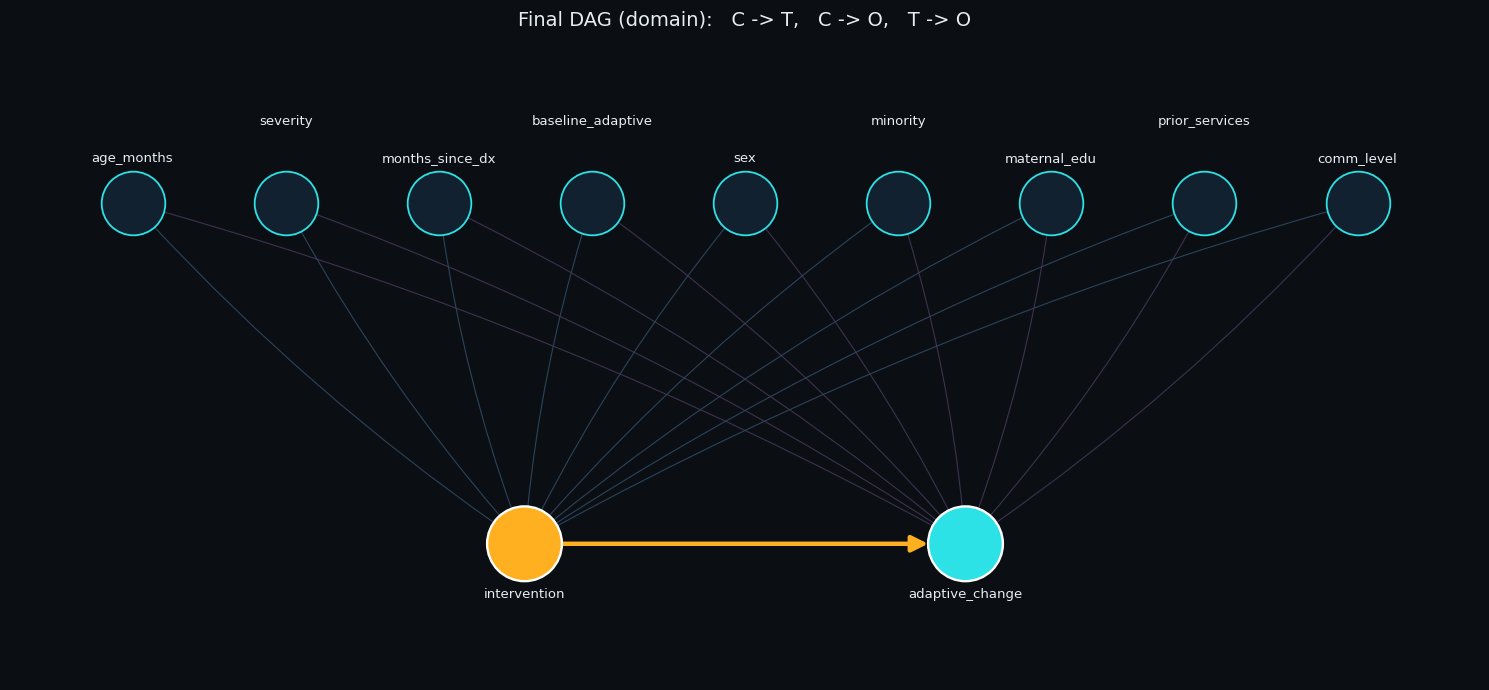

In [3]:
C_num = ["age_months", "severity", "months_since_dx", "baseline_adaptive", "sex", "minority"]
disc  = [T, O] + C_num
X = df[disc].astype(float).to_numpy()
cg = pc(X, alpha=0.05, indep_test="fisherz", show_progress=False, node_names=disc)
G = cg.G.graph
directed, undirected = [], []
for i in range(len(disc)):
    for j in range(i + 1, len(disc)):
        a, b = G[i, j], G[j, i]
        if a == -1 and b == 1:    directed.append((disc[i], disc[j]))
        elif a == 1 and b == -1:  directed.append((disc[j], disc[i]))
        elif a == -1 and b == -1: undirected.append((disc[i], disc[j]))
print("CPDAG directed  :", directed)
print("CPDAG undirected:", undirected)

D = nx.DiGraph()
D.add_nodes_from([T, O] + CONF)
for c in CONF:
    D.add_edge(c, T)
    D.add_edge(c, O)
D.add_edge(T, O)
print("DAG edges  :", list(D.edges()))
print("DAG acyclic:", nx.is_directed_acyclic_graph(D))
print("SCE : C_j = f_Cj(U_Cj) ;  T = f_T(C, U_T) ;  O = f_O(T, C, U_O)")
print("SCM : V =", [T, O] + CONF)
print("      U = {U_T, U_O, U_Cj} ;  F = SCE ;  M = (U, V, F, P(U))")

dsep = nx.is_d_separator if hasattr(nx, "is_d_separator") else nx.d_separated
Dm = D.copy()
Dm.remove_edges_from([(T, v) for v in list(D.successors(T))])
print("Backdoor set =", CONF)
print("  valid (T _||_ O | C in G_underline_T):", dsep(Dm, {T}, {O}, set(CONF)))
print("  C has no descendant of T:", len(set(CONF) & nx.descendants(D, T)) == 0)

k = len(CONF)
pos = {c: (i / (k - 1), 1.0) for i, c in enumerate(CONF)}
pos[T], pos[O] = (0.32, 0.0), (0.68, 0.0)
fig, ax = plt.subplots(figsize=(15, 7))
ax.set_facecolor("#0b0f14"); fig.patch.set_facecolor("#0b0f14")
nx.draw_networkx_edges(D, pos, edgelist=[(c, T) for c in CONF], edge_color="#33506e",
                       arrows=True, arrowsize=8, width=0.8, alpha=0.8, node_size=2100,
                       connectionstyle="arc3,rad=0.06", ax=ax)
nx.draw_networkx_edges(D, pos, edgelist=[(c, O) for c in CONF], edge_color="#4a3a5e",
                       arrows=True, arrowsize=8, width=0.8, alpha=0.8, node_size=2100,
                       connectionstyle="arc3,rad=-0.06", ax=ax)
nx.draw_networkx_edges(D, pos, edgelist=[(T, O)], edge_color="#ffb020",
                       arrows=True, arrowsize=24, width=3.2, node_size=2900, ax=ax)
nx.draw_networkx_nodes(D, pos, nodelist=CONF, node_color="#12212f", node_size=2100,
                       edgecolors="#2de2e6", linewidths=1.3, ax=ax)
nx.draw_networkx_nodes(D, pos, nodelist=[T, O], node_color=["#ffb020", "#2de2e6"],
                       node_size=2900, edgecolors="w", linewidths=1.7, ax=ax)
lp = {c: (pos[c][0], 1.13 if i % 2 == 0 else 1.24) for i, c in enumerate(CONF)}
lp[T], lp[O] = (0.32, -0.15), (0.68, -0.15)
nx.draw_networkx_labels(D, pos=lp, font_size=9.5, font_color="#e6edf3", ax=ax)
ax.set_title("Final DAG (domain):   C -> T,   C -> O,   T -> O", color="#e6edf3", fontsize=14, pad=18)
ax.set_ylim(-0.4, 1.45); ax.set_xlim(-0.1, 1.1); ax.axis("off")
plt.tight_layout(); plt.show()

## Identification

In [4]:
RHS = " + ".join(C_cont + [f"C({c})" for c in C_cat])
outcome = smf.ols(f"{O} ~ {T} + {RHS}", data=df).fit(cov_type="HC1")
d1 = df.assign(**{T: 1.0})
d0 = df.assign(**{T: 0.0})
mu1 = outcome.predict(d1)
mu0 = outcome.predict(d0)
ATE_ident = (mu1 - mu0).mean()
print("ATE (identification):", ATE_ident)

ATE (identification): 7.530992106989925


## Estimation

In [5]:
b1 = outcome.params[T]
ci = outcome.conf_int().loc[T].values
ATE_est = b1
print(pd.Series({"ATE_est": ATE_est, "SE": outcome.bse[T], "t": outcome.tvalues[T],
                 "p": outcome.pvalues[T], "CI_low": ci[0], "CI_high": ci[1]}))

ATE_est    7.530992e+00
SE         4.875179e-01
t          1.544762e+01
p          7.827775e-54
CI_low     6.575475e+00
CI_high    8.486510e+00
dtype: float64


# DEĞERLENDİRME

## Sensitivity

                     beta_T    beta_O   ATE_adj  robust
var                                                    
age_months        -0.025137 -1.840019  7.484740    True
severity           0.175694 -1.233831  7.747769    True
months_since_dx    0.005526 -1.597354  7.539819    True
baseline_adaptive -0.153351 -0.192577  7.501460    True
sex               -0.003229 -0.353795  7.529850    True
minority          -0.091222 -0.673998  7.469508    True
   beta_T     beta_O    ATE_adj
0    -1.0 -11.296488  -3.765496
1    -1.0  -9.025837  -1.494845
2    -1.0  -6.755186   0.775806
3    -1.0  -4.484536   3.046457
4    -1.0  -2.213885   5.317107
5    -1.0   0.056766   7.587758
6    -1.0   2.327417   9.858409
7    -1.0   4.598068  12.129060
8    -1.0   6.868719  14.399711
9    -1.0   9.139370  16.670362


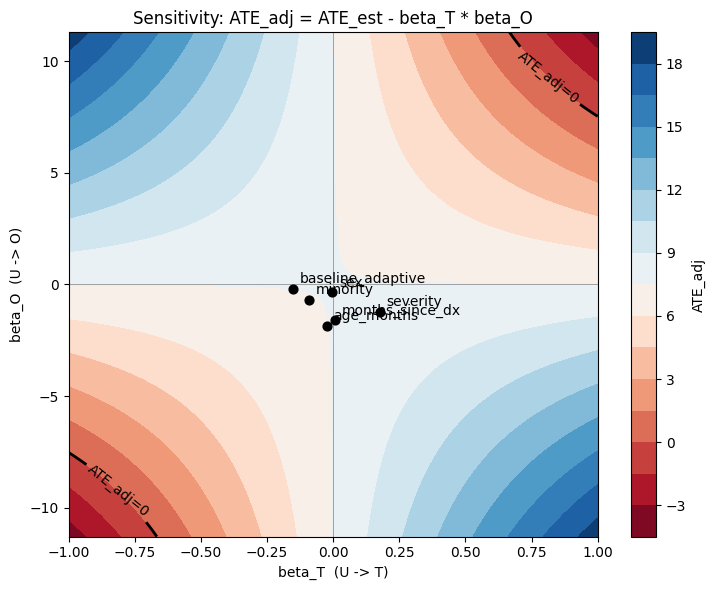

In [6]:
bench_vars = C_cont + ["sex", "minority"]
Z = df.copy()
for c in C_cont:
    Z[c] = (Z[c] - Z[c].mean()) / Z[c].std()
for c in ["sex", "minority"]:
    Z[c] = Z[c].astype(float)

rows = []
for c in bench_vars:
    bT = smf.ols(f"{T} ~ {c}", data=Z).fit().params[c]
    bO = smf.ols(f"{O} ~ {c}", data=Z).fit().params[c]
    adj = ATE_est - bT * bO
    robust = (np.sign(adj) == np.sign(ATE_est)) and (abs(adj) > 0.5 * abs(ATE_est))
    rows.append((c, bT, bO, adj, robust))
benchmark = pd.DataFrame(rows, columns=["var", "beta_T", "beta_O", "ATE_adj", "robust"]).set_index("var")
print(benchmark)

bT_max = max(1.0, 1.2 * benchmark.beta_T.abs().max())
bO_max = max(1.5 * abs(ATE_est), 1.2 * benchmark.beta_O.abs().max())
gT = np.linspace(-bT_max, bT_max, 200)
gO = np.linspace(-bO_max, bO_max, 200)
BT, BO = np.meshgrid(gT, gO)
ADJ = ATE_est - BT * BO
tablo = pd.DataFrame({"beta_T": BT.ravel(), "beta_O": BO.ravel(), "ATE_adj": ADJ.ravel()})
print(tablo.iloc[::4000].reset_index(drop=True))

plt.figure(figsize=(7.5, 6))
cf = plt.contourf(BT, BO, ADJ, levels=20, cmap="RdBu")
z0 = plt.contour(BT, BO, ADJ, levels=[0], colors="k", linewidths=2)
plt.clabel(z0, fmt="ATE_adj=0")
plt.colorbar(cf, label="ATE_adj")
plt.scatter(benchmark.beta_T, benchmark.beta_O, c="black", s=40, zorder=5)
for c in benchmark.index:
    plt.annotate(c, (benchmark.loc[c, "beta_T"], benchmark.loc[c, "beta_O"]),
                 textcoords="offset points", xytext=(5, 4))
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("beta_T  (U -> T)")
plt.ylabel("beta_O  (U -> O)")
plt.title("Sensitivity: ATE_adj = ATE_est - beta_T * beta_O")
plt.tight_layout()
plt.show()